In [1]:
import uproot
import time
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
from collections import Counter

from sklearn.cluster import DBSCAN
import hdbscan
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn import metrics
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.metrics import pairwise_distances
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors

from scipy.interpolate import UnivariateSpline


In [2]:
file_path = "/Users/edwar/OneDrive/Documents/Documents/2025/RS_2015_MagDown_No_Offline_reduced.root" #Smaller RS
#file_path = "/Users/edwar/OneDrive/Documents/2025/input_with_sweights_check_full_WS.root" #Full WS
#file_path = "/Users/edwar/OneDrive/Documents/2025/input_with_sweights_with_log.root"#Full RS
tree_name = "DecayTree"

with uproot.open(file_path) as file:
    tree = file[tree_name]
    #variables = ["Dst_pi_TRACK_GhostProb", "verified_id_D0_Part_OS_Pi_1_ProbNNpi"]
    variables = ["D0_IPCHI2_OWNPV", "cos_theta_pis_trig"
             , "Dst_pi_ProbNNpi_common", "D0_Loki_DOCAMAX", "Dst_pi_IPCHI2_OWNPV"
             , "Dst_pi_PT", "D0_Loki_VCHI2NDOF", "Dst_pi_TRACK_CHI2NDOF"
             , "Dst_pi_TRACK_GhostProb", "verified_id_D0_Part_OS_Pi_1_ProbNNpi"]

    data = tree.arrays(variables, library="pd")
    D0_MM_data = tree["D0_MM"].array(library="pd")
    deltam_ReFit_data = tree["deltam_ReFit"].array(library="pd")

data['D0_IPCHI2_OWNPV'] = np.log(data['D0_IPCHI2_OWNPV'])
data['Dst_pi_ProbNNpi_common'] = np.log(data['Dst_pi_ProbNNpi_common'])
data['Dst_pi_IPCHI2_OWNPV'] = np.log(data['Dst_pi_IPCHI2_OWNPV'])
data['Dst_pi_TRACK_GhostProb'] = np.log(data['Dst_pi_TRACK_GhostProb'])

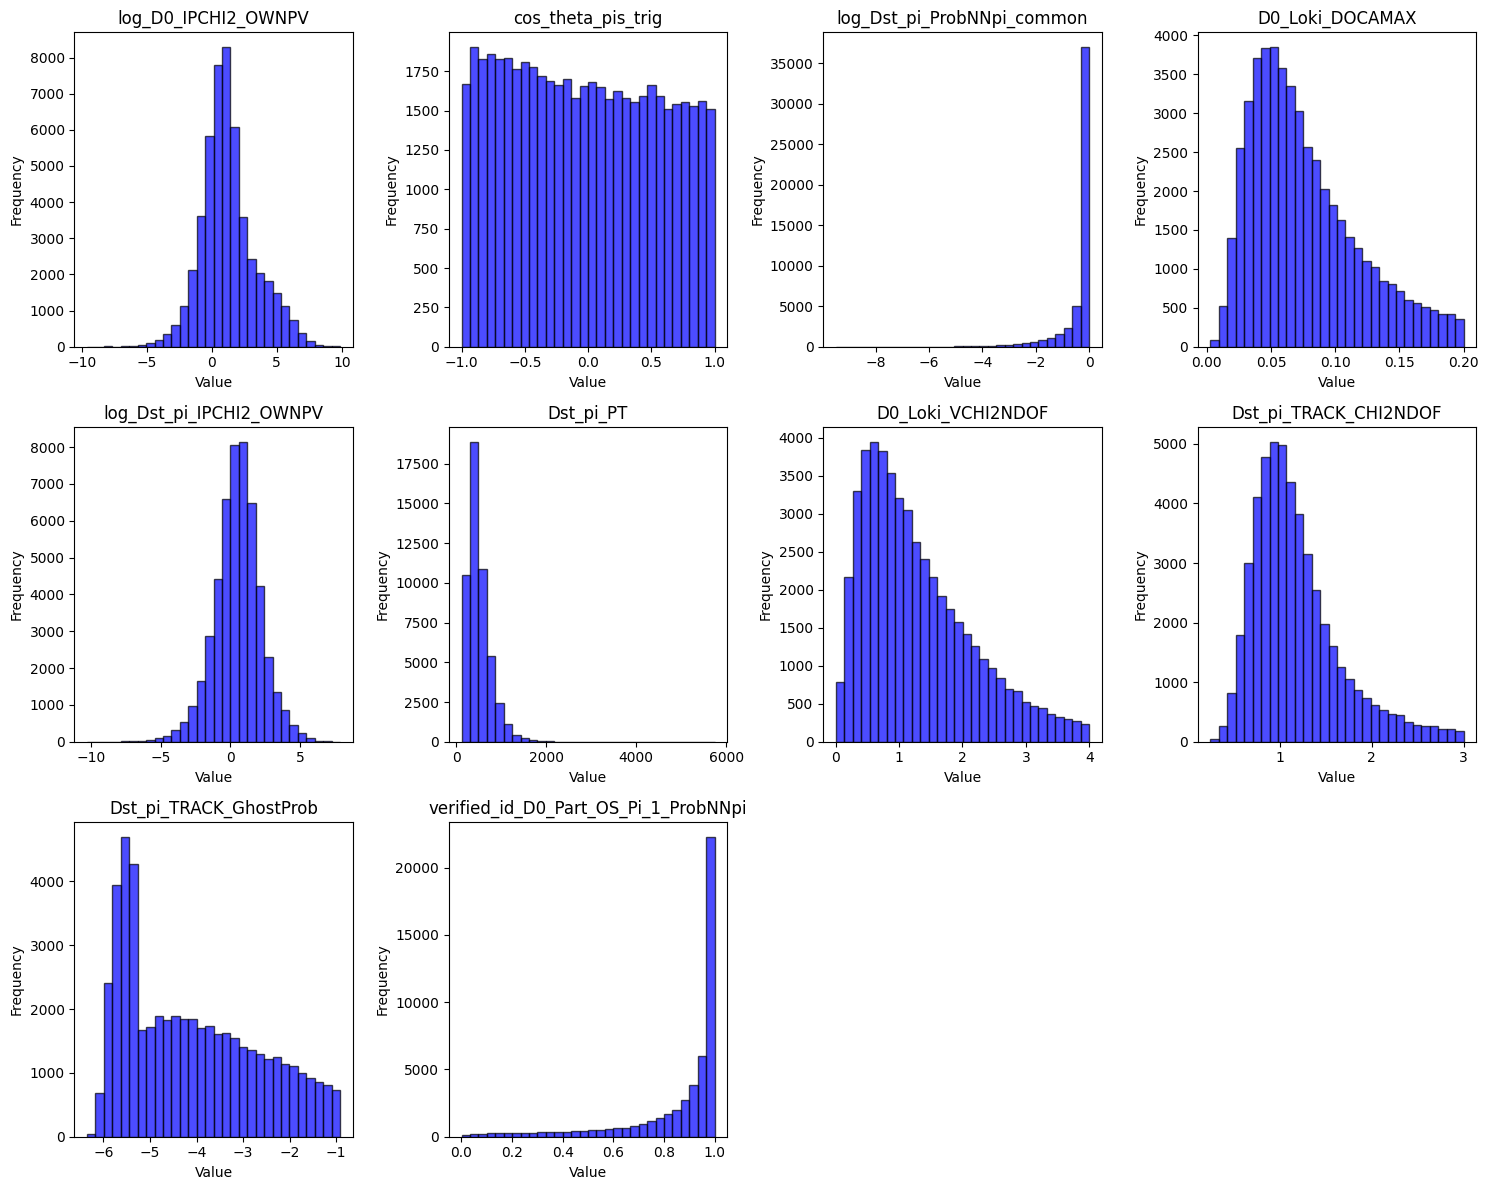

--------------------------------------------------------------------
MEANS: 
 D0_IPCHI2_OWNPV                           1.281121
cos_theta_pis_trig                       -0.034295
Dst_pi_ProbNNpi_common                   -0.365819
D0_Loki_DOCAMAX                           0.076218
Dst_pi_IPCHI2_OWNPV                       0.524099
Dst_pi_PT                               503.865088
D0_Loki_VCHI2NDOF                         1.289587
Dst_pi_TRACK_CHI2NDOF                     1.180563
Dst_pi_TRACK_GhostProb                   -4.110388
verified_id_D0_Part_OS_Pi_1_ProbNNpi      0.855103
dtype: float64
--------------------------------------------------------------------
STANDARD DEVIATION: 
 D0_IPCHI2_OWNPV                           2.098611
cos_theta_pis_trig                        0.577610
Dst_pi_ProbNNpi_common                    0.687495
D0_Loki_DOCAMAX                           0.042031
Dst_pi_IPCHI2_OWNPV                       1.675835
Dst_pi_PT                               255.198358


In [3]:
plt.figure(figsize=(15, 12))

for i, variable in enumerate(variables):
    plt.subplot(3, 4, i + 1)
    plt.hist(data[variable], bins=30, alpha=0.7, color='blue', edgecolor='black')
    if i in [0, 2, 4]:
        plt.title(f"log_{variable}")
    else:
        plt.title(variable)
    plt.xlabel('Value')
    plt.ylabel('Frequency')


"""for i, variable in enumerate(variables_mass):
    plt.subplot(3, 4, i + 1)
    plt.hist(data_mass[variable], bins=30, alpha=0.7, color='blue', edgecolor='black')
    plt.title(variable)
    plt.xlabel('Value')
    plt.ylabel('Frequency')"""
plt.tight_layout()
plt.show()
print("--------------------------------------------------------------------")
print(f'MEANS: \n {data.mean()}')
print("--------------------------------------------------------------------")
print(f'STANDARD DEVIATION: \n {data.std()}')
print("--------------------------------------------------------------------")

In [5]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data[variables])
print(scaled_data.shape)

(50000, 10)


(50000, 10)


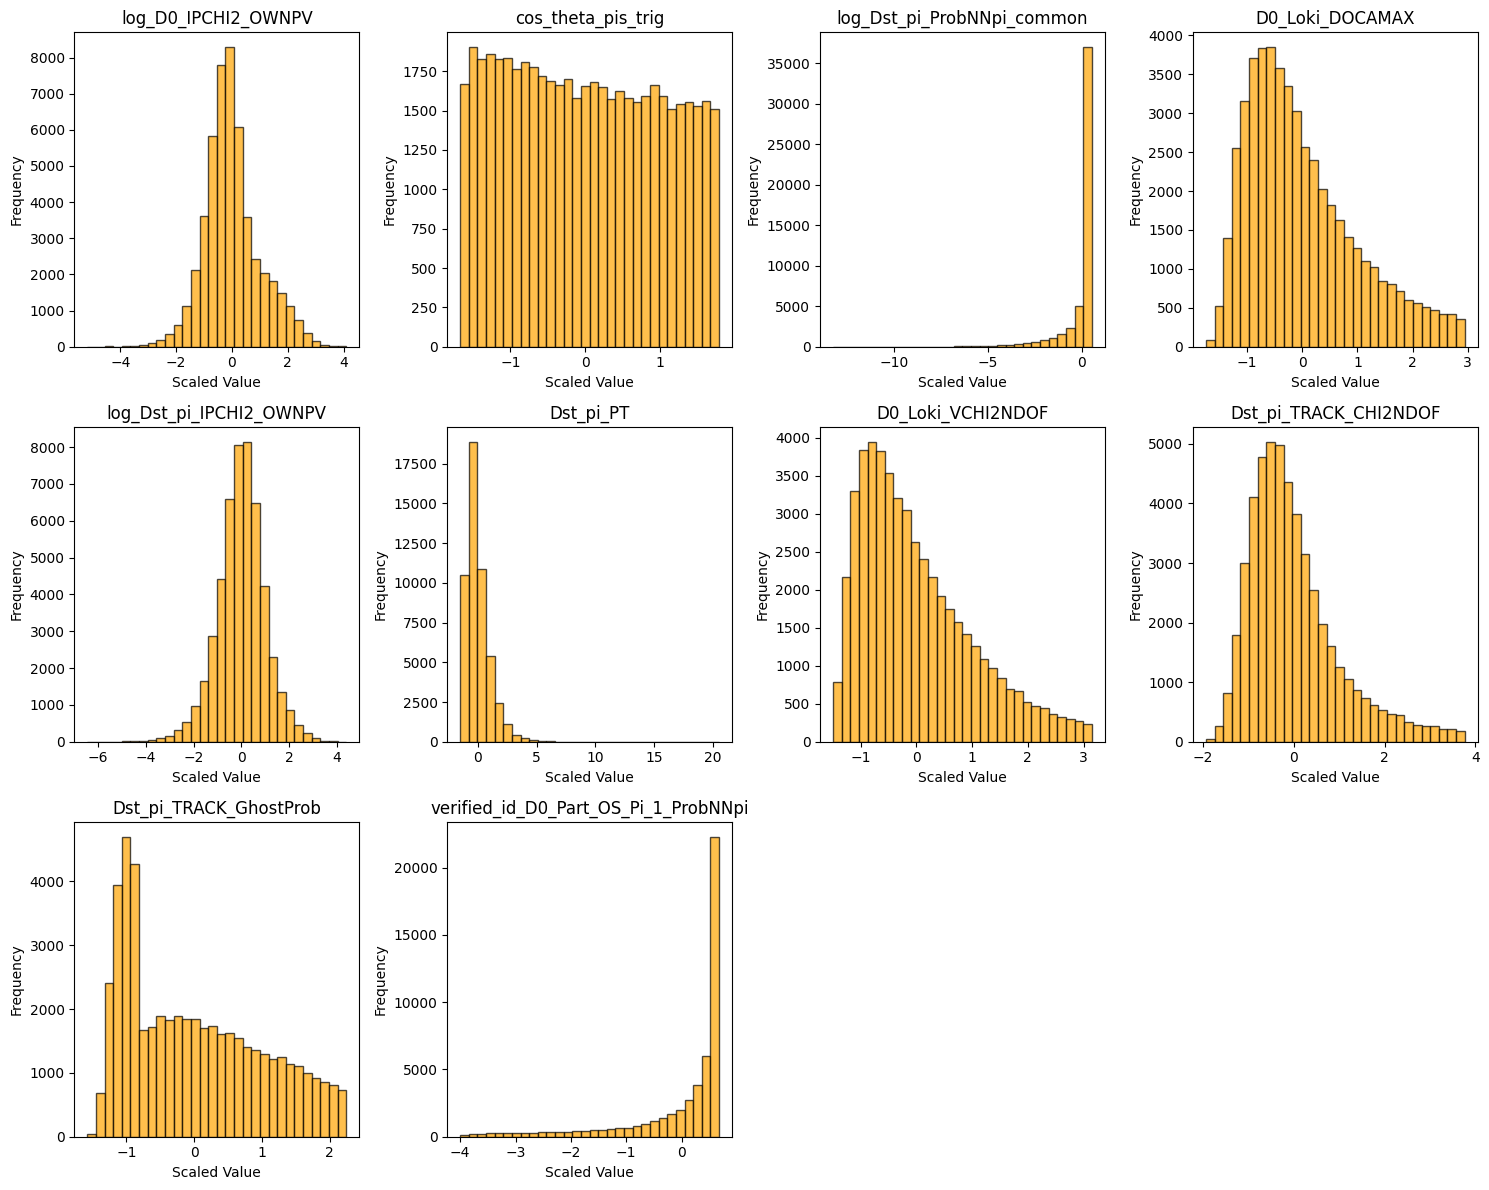

--------------------------------------------------------------------
MEANS: 
 D0_IPCHI2_OWNPV                        -1.833200e-17
cos_theta_pis_trig                     -2.785328e-17
Dst_pi_ProbNNpi_common                 -3.140599e-17
D0_Loki_DOCAMAX                        -2.750511e-16
Dst_pi_IPCHI2_OWNPV                     2.255973e-17
Dst_pi_PT                              -3.224443e-16
D0_Loki_VCHI2NDOF                      -1.222134e-16
Dst_pi_TRACK_CHI2NDOF                  -6.448175e-17
Dst_pi_TRACK_GhostProb                 -6.295586e-16
verified_id_D0_Part_OS_Pi_1_ProbNNpi    4.116885e-16
dtype: float64
--------------------------------------------------------------------
STANDARD DEVIATION: 
 D0_IPCHI2_OWNPV                         1.0
cos_theta_pis_trig                      1.0
Dst_pi_ProbNNpi_common                  1.0
D0_Loki_DOCAMAX                         1.0
Dst_pi_IPCHI2_OWNPV                     1.0
Dst_pi_PT                               1.0
D0_Loki_VCHI2NDOF     

In [6]:
scaled_df = pd.DataFrame(scaled_data, columns=variables)
print(scaled_df.shape)
# Plot the scaled data
plt.figure(figsize=(15, 12))

for i, variable in enumerate(variables):
    plt.subplot(3, 4, i + 1)  # Create a 3x4 grid of subplots
    plt.hist(scaled_df[variable], bins=30, alpha=0.7, color='orange', edgecolor='black')
    if i in [0, 2, 4]:
        plt.title(f"log_{variable}")
    else:
        plt.title(variable)
    plt.xlabel('Scaled Value')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

print("--------------------------------------------------------------------")
print(f'MEANS: \n {scaled_df.mean()}')
print("--------------------------------------------------------------------")
print(f'STANDARD DEVIATION: \n {scaled_df.std().round(3)}')
print("--------------------------------------------------------------------")

In [7]:
print(scaled_data.shape)
sampled_data = pd.DataFrame(scaled_data)
#k = 2n - 1, where n is the number of variables considered.
k = 19
nn = NearestNeighbors(n_neighbors=k)
nbrs = nn.fit(sampled_data)
distances, _ = nbrs.kneighbors(sampled_data)
k_distances = distances[:, k - 1]#Kth distance
# Sorting kth distance
k_distances = np.sort(k_distances)

(50000, 10)


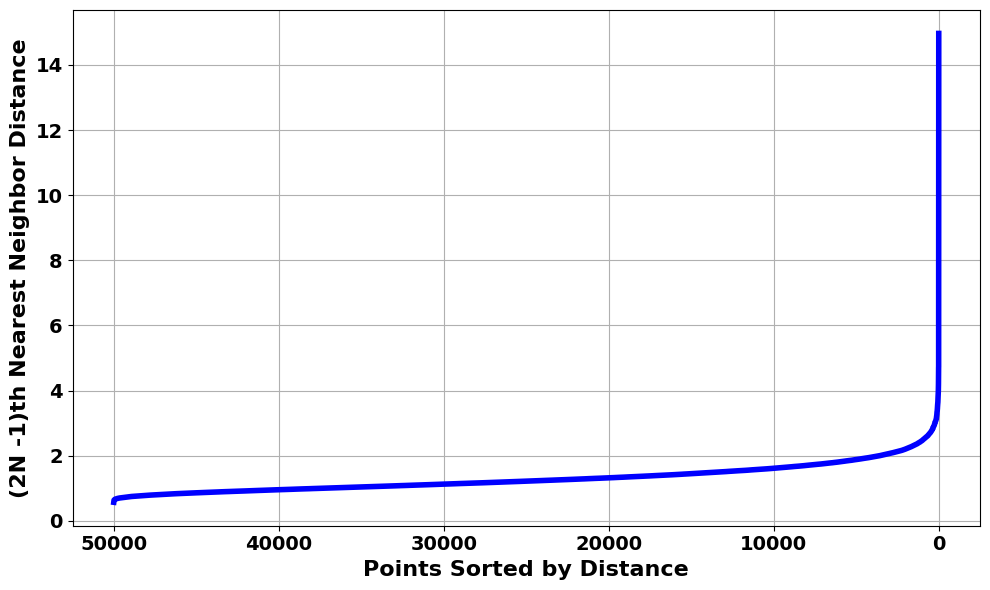

In [8]:
# Reverse the k-distance array for proper ordering
k_distances = k_distances[::-1]

# Define the x-axis points corresponding to sorted distances
x = np.arange(len(k_distances))
y = k_distances

plt.figure(figsize=(10, 6))
plt.plot(x, y, color='blue', linewidth=4)

# Optionally, uncomment the lines below if using knee detection:
# kneedle = KneeLocator(x, y, S=1.0, curve="convex", direction="decreasing")
# kneedle.plot_knee()

# Set title and labels with larger, bold fonts for a professional look

plt.xlabel("Points Sorted by Distance", fontsize=16, fontweight='bold')
plt.ylabel("(2N -1)th Nearest Neighbor Distance", fontsize=16, fontweight='bold')

# Invert x-axis to reflect descending order of distances
plt.gca().invert_xaxis()

# Customize tick parameters
plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')

plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
print(sampled_data.shape)
dbscan = DBSCAN(eps=2.8, min_samples=20)
#dbscan = DBSCAN(eps=0.025, min_samples=20) #For 2 Variables 
#hdbscan_clusterer = hdbscan.HDBSCAN(min_cluster_size=10, min_samples=5, cluster_selection_method='eom')
#labels = hdbscan_clusterer.fit_predict(sampled_data)
labels = dbscan.fit_predict(sampled_data)
original_sampled_data = sampled_data.copy()

(50000, 10)


In [10]:
sampled_data['cluster_labels'] = labels
print(sampled_data.shape)

(50000, 11)


In [11]:
clusters_of_interest = [-1, 0]
core_points_per_cluster = []
for cluster in clusters_of_interest:
    core_points_indices = sampled_data[sampled_data['cluster_labels'] == cluster].index
    core_point = sampled_data.iloc[core_points_indices[0]].drop('cluster_labels')
    core_point_with_label = pd.Series({'cluster_label': cluster})
    core_point = pd.concat([core_point, core_point_with_label])
    core_points_per_cluster.append(core_point)

core_points_df = pd.DataFrame(core_points_per_cluster)

print("Core points (2D) for noise (-1) and cluster 0:")
print(core_points_df)
core_points_array = core_points_df.drop('cluster_label', axis=1).values  # Exclude cluster label column
print("Core points (2D) array format:")
print(core_points_array)

Core points (2D) for noise (-1) and cluster 0:
          0         1         2         3         4         5         6  \
0 -2.454388  0.853992  0.385050  1.414241 -1.206372  1.508707  0.116433   
1  0.185379  0.786268  0.504303  0.352811 -0.516810  0.316445  1.597691   

          7         8         9  cluster_label  
0 -0.781646  0.653224  0.649741           -1.0  
1 -1.260811 -1.035147  0.651036            0.0  
Core points (2D) array format:
[[-2.45438847  0.85399164  0.3850502   1.41424125 -1.20637205  1.50870701
   0.11643345 -0.7816465   0.65322378  0.64974128]
 [ 0.18537903  0.7862676   0.50430285  0.35281061 -0.51681043  0.31644483
   1.59769123 -1.26081148 -1.0351474   0.65103574]]


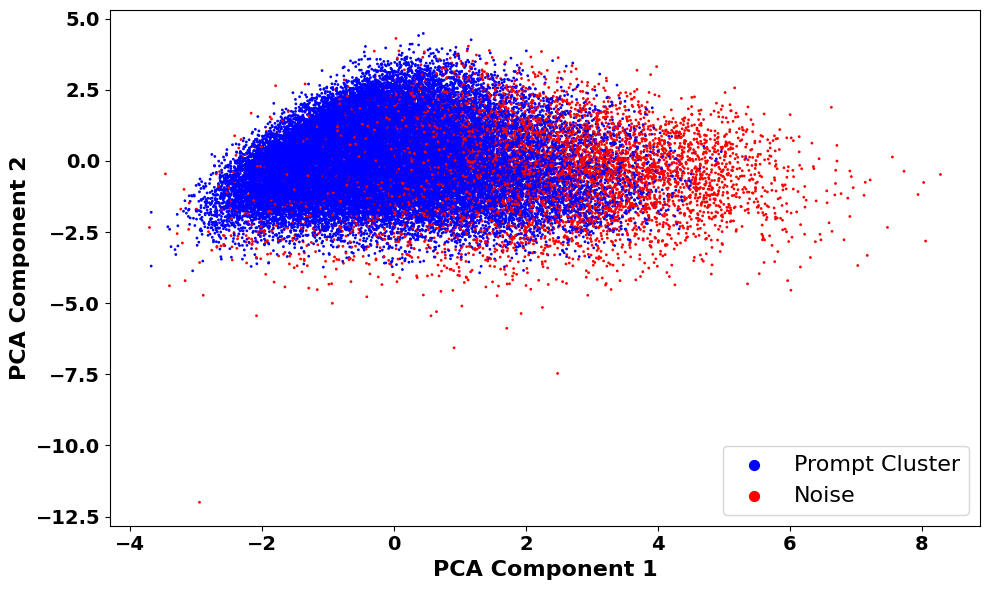

cluster_labels
 0    43585
-1     6415
Name: count, dtype: int64
Filtered cluster counts: Counter({0: 43585, -1: 6415})
(50000, 11)


In [12]:
# Ensure column names are strings
sampled_data.columns = sampled_data.columns.astype(str)

# Drop the 'cluster_labels' column and fit PCA
pca_plot = PCA(n_components=2)
pca_result_plot = pca_plot.fit_transform(sampled_data.drop('cluster_labels', axis=1))

# Filter for clusters 0 and -1
mask = sampled_data['cluster_labels'].isin([0, -1])
filtered_pca_result = pca_result_plot[mask]
filtered_labels = sampled_data.loc[mask, 'cluster_labels']

# Define a custom color map with renamed clusters
colors = {0: 'blue', -1: 'red'}
labels = {0: 'Prompt Cluster', -1: 'Noise'}
color_list = [colors[label] for label in filtered_labels]

# Plot only the filtered clusters
plt.figure(figsize=(10, 6))
scatter = plt.scatter(filtered_pca_result[:, 0], 
                      filtered_pca_result[:, 1], 
                      c=color_list, s=1)

# Add legend for renamed clusters
for cluster_label, color in colors.items():
    plt.scatter([], [], c=color, label=labels[cluster_label], s=50)
plt.legend( fontsize=16, title_fontsize=14)

# Plot details with enhanced aesthetics
#plt.title('DBSCAN Clustering Results: Prompt Cluster and Noise', fontsize=18, fontweight='bold')
plt.xlabel('PCA Component 1', fontsize=16, fontweight='bold')
plt.ylabel('PCA Component 2', fontsize=16, fontweight='bold')

# Customizing tick labels for consistency
plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Print cluster counts
print(sampled_data['cluster_labels'].value_counts())

cluster_counts = Counter(filtered_labels)
print("Filtered cluster counts:", cluster_counts)
print(sampled_data.shape)


In [13]:
sampled_data['D0_MM'] = D0_MM_data.sample(frac=1, random_state=1).values
sampled_data['deltam_ReFit'] = deltam_ReFit_data.sample(frac=1, random_state=1).values
print(sampled_data['cluster_labels'].value_counts())
print(sampled_data.shape)

cluster_labels
 0    43585
-1     6415
Name: count, dtype: int64
(50000, 13)


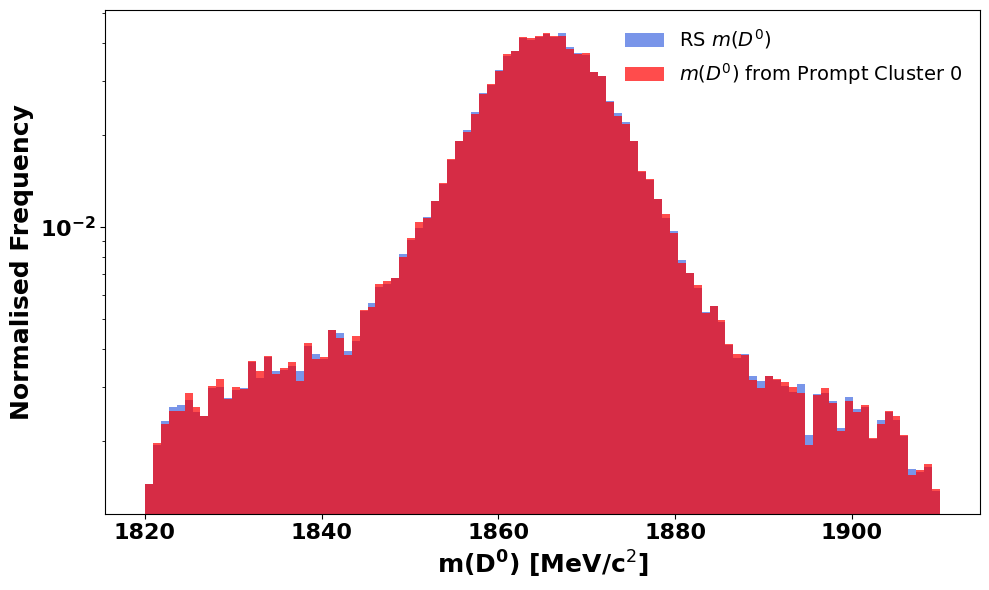

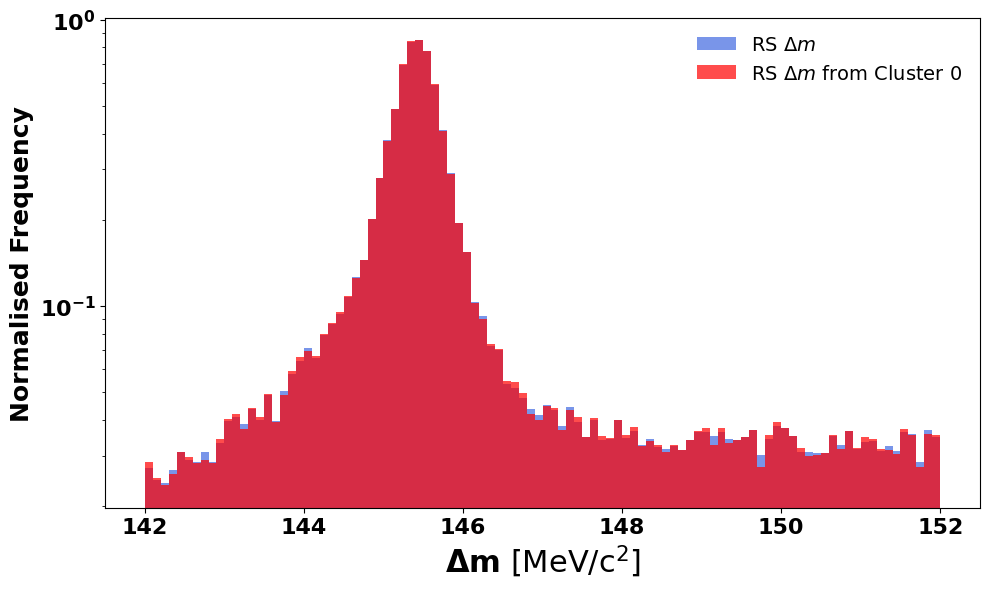

In [14]:
cluster0 = 0
cluster1 = -1

# Filter events by cluster
cluster_events0 = sampled_data[sampled_data['cluster_labels'] == cluster0]
cluster_events1 = sampled_data[sampled_data['cluster_labels'] == cluster1]

cluster_events0_plot_D0 = cluster_events0['D0_MM']
cluster_events1_plot_D0 = cluster_events1['D0_MM']
data_plot_D0 = sampled_data['D0_MM']

cluster_events0_plot_Deltam = cluster_events0['deltam_ReFit']
cluster_events1_plot_Deltam = cluster_events1['deltam_ReFit']
data_plot_Deltam = sampled_data['deltam_ReFit']

# Plot D0_MM
plt.figure(figsize=(10, 6))
plt.hist(data_plot_D0, bins=100, alpha=0.7, color='royalblue', label='RS $m(D^0)$', density=True, range=[1820, 1910])
plt.hist(cluster_events0_plot_D0, bins=100, alpha=0.7, color='red', label=f'$m(D^0)$ from Prompt Cluster {cluster0}', density=True, range=[1820, 1910])

plt.xlabel(r"$\mathbf{m(D^0)}$ [MeV/c$^2$]", fontsize=18, fontweight='bold')
plt.ylabel("Normalised Frequency", fontsize=18, fontweight='bold')
plt.legend(fontsize=14, loc='upper right', frameon=False)
plt.xticks(fontsize=16, fontweight='bold')
plt.yticks(fontsize=16, fontweight='bold')
plt.yscale('log')
plt.tight_layout()
plt.show()

# Plot deltam_ReFit
plt.figure(figsize=(10, 6))
plt.hist(data_plot_Deltam, bins=100, alpha=0.7, color='royalblue', label='RS $\Delta m$', density=True, range=[142, 152])
plt.hist(cluster_events0_plot_Deltam, bins=100, alpha=0.7, color='red', label=f'RS $\Delta m$ from Cluster {cluster0}', density=True, range=[142, 152])

plt.xlabel(r"$\mathbf{\Delta m}$ [MeV/c$^2$]", fontsize=22)
plt.ylabel("Normalised Frequency", fontsize=18, fontweight='bold')
plt.legend(fontsize=14, loc='upper right', frameon=False)
plt.xticks(fontsize=16, fontweight='bold')
plt.yticks(fontsize=16, fontweight='bold')
plt.yscale('log')
plt.tight_layout()
plt.show()

C:\Users\edwar\AppData\Local\Temp\ipykernel_144528\18906668.py:7: RuntimeWarning: invalid value encountered in divide
  hist_diff0 = abs(hist_cluster0 / hist_all)


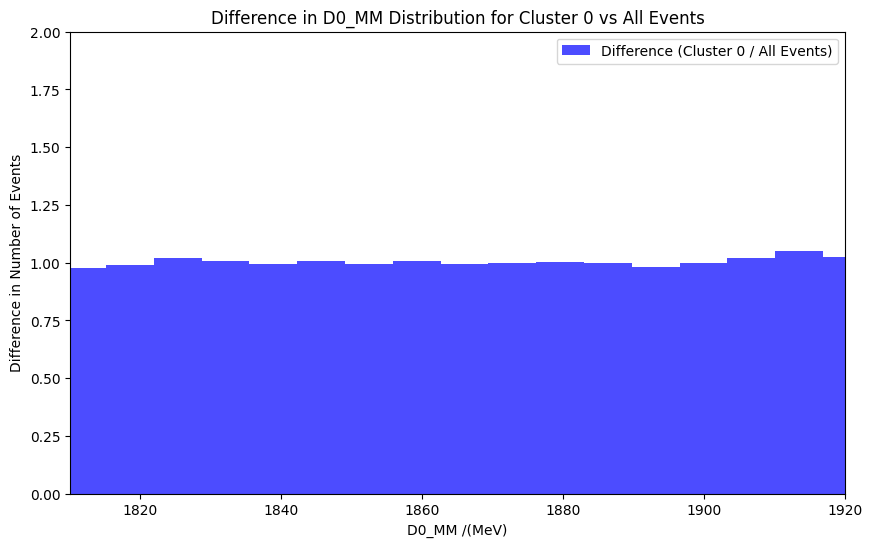

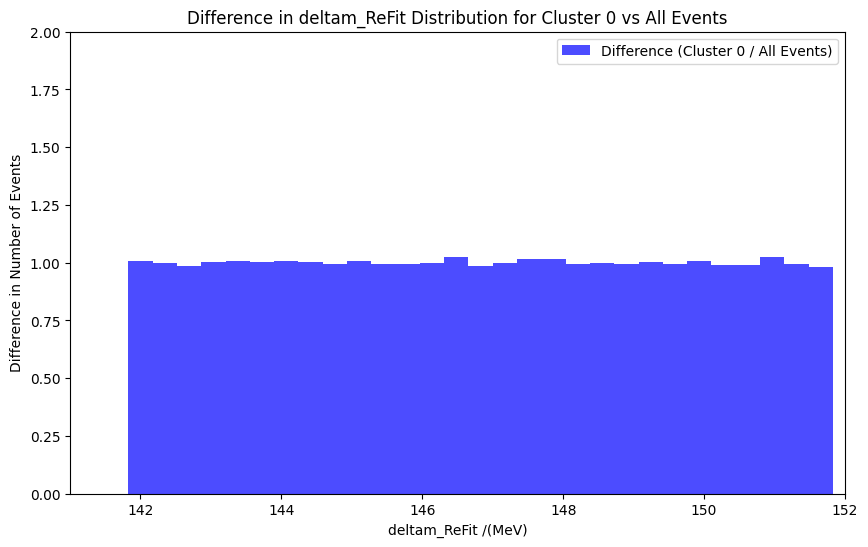

(50000, 13)


In [15]:
bins = np.linspace(min(sampled_data['D0_MM']), max(sampled_data['D0_MM']), 30)  # Define bin edges
bins1 = np.linspace(min(sampled_data['deltam_ReFit']), max(sampled_data['deltam_ReFit']), 30)
#All events
hist_all, _ = np.histogram(sampled_data['D0_MM'], bins=bins, density = True)
#Cluster0 events
hist_cluster0, _ = np.histogram(cluster_events0['D0_MM'], bins=bins, density = True)
hist_diff0 = abs(hist_cluster0 / hist_all)

plt.figure(figsize=(10, 6))
plt.bar(bins[:-1], hist_diff0, width=np.diff(bins), alpha=0.7, color='blue', label=f'Difference (Cluster {cluster0} / All Events)')
#plt.xlim(141,152)
plt.xlim(1810, 1920)
plt.ylim(0, 2)
plt.title(f"Difference in D0_MM Distribution for Cluster {cluster0} vs All Events")
plt.xlabel("D0_MM /(MeV)")
plt.ylabel("Difference in Number of Events")
plt.legend()
plt.show()

hist_all1, _ = np.histogram(sampled_data['deltam_ReFit'], bins=bins1, density = True)
hist_cluster1, _ = np.histogram(cluster_events0['deltam_ReFit'], bins=bins1, density = True)
hist_diff1 = abs(hist_cluster1 / hist_all1)

plt.figure(figsize=(10, 6))
plt.bar(bins1[:-1], hist_diff1, width=np.diff(bins1), alpha=0.7, color='blue', label=f'Difference (Cluster {cluster0} / All Events)')
plt.xlim(141,152)
plt.ylim(0, 2)
plt.title(f"Difference in deltam_ReFit Distribution for Cluster {cluster0} vs All Events")
plt.xlabel("deltam_ReFit /(MeV)")
plt.ylabel("Difference in Number of Events")
plt.legend()
plt.show()
print(sampled_data.shape)

In [16]:
cluster_counts = Counter(labels)
num_clusters = len([label for label in cluster_counts if label != -1]) #excluding noise (-1)

print(f"Estimated number of clusters (excluding noise): {num_clusters}")
print("Cluster counts:", cluster_counts)
print(sampled_data.shape)

Estimated number of clusters (excluding noise): 1
Cluster counts: Counter({0: 'Prompt Cluster', -1: 'Noise'})
(50000, 13)


In [18]:
file_path_ws = "/Users/edwar/OneDrive/Documents/Documents/2025/WS_2015_MagDown_No_Offline_reduced.root" #Full WS
tree_name_ws = "DecayTree"

with uproot.open(file_path_ws) as file:
    tree_ws = file[tree_name_ws]
    #variables_ws = ["Dst_pi_TRACK_GhostProb", "verified_id_D0_Part_OS_Pi_1_ProbNNpi"]
    variables_ws = ["D0_IPCHI2_OWNPV", "cos_theta_pis_trig"
             , "Dst_pi_ProbNNpi_common", "D0_Loki_DOCAMAX", "Dst_pi_IPCHI2_OWNPV"
             , "Dst_pi_PT", "D0_Loki_VCHI2NDOF", "Dst_pi_TRACK_CHI2NDOF"
             , "Dst_pi_TRACK_GhostProb", "verified_id_D0_Part_OS_Pi_1_ProbNNpi"]

    data_ws = tree_ws.arrays(variables_ws, library="pd")
    D0_MM_data_ws = tree_ws["D0_MM"].array(library="pd")
    deltam_ReFit_data_ws = tree_ws["deltam_ReFit"].array(library="pd")

data_ws['D0_IPCHI2_OWNPV'] = np.log(data_ws['D0_IPCHI2_OWNPV'])
data_ws['Dst_pi_ProbNNpi_common'] = np.log(data_ws['Dst_pi_ProbNNpi_common'])
data_ws['Dst_pi_IPCHI2_OWNPV'] = np.log(data_ws['Dst_pi_IPCHI2_OWNPV'])
data_ws['Dst_pi_TRACK_GhostProb'] = np.log(data_ws['Dst_pi_TRACK_GhostProb'])

In [19]:
scaler_ws = StandardScaler()
scaled_data_ws = scaler.fit_transform(data_ws[variables])

In [20]:
core_point_cluster_neg1 = core_points_array[0]
core_point_cluster_0 = core_points_array[1]
print(core_points_array[0])
print(core_points_array[1])
# Step 1: Compute squared Euclidean distance to cluster -1 core point
dist_to_core_neg1 = np.sum((scaled_data_ws - core_point_cluster_neg1) ** 2, axis=1)

# Step 2: Compute squared Euclidean distance to cluster 0 core point
dist_to_core_0 = np.sum((scaled_data_ws - core_point_cluster_0) ** 2, axis=1)

# Step 3: Assign cluster labels (-1 for closer to cluster -1 core point, 0 otherwise)
labels_ws = np.where(dist_to_core_neg1 < dist_to_core_0, -1, 0)

# Step 4: Add the cluster labels to the ws_data DataFrame
data_ws['cluster_labels'] = labels_ws

# Step 5: Inspect the results
print(data_ws[['cluster_labels']].head())
print(data_ws['cluster_labels'].value_counts())

[-2.45438847  0.85399164  0.3850502   1.41424125 -1.20637205  1.50870701
  0.11643345 -0.7816465   0.65322378  0.64974128]
[ 0.18537903  0.7862676   0.50430285  0.35281061 -0.51681043  0.31644483
  1.59769123 -1.26081148 -1.0351474   0.65103574]
   cluster_labels
0               0
1               0
2               0
3               0
4               0
cluster_labels
 0    41223
-1     8777
Name: count, dtype: int64


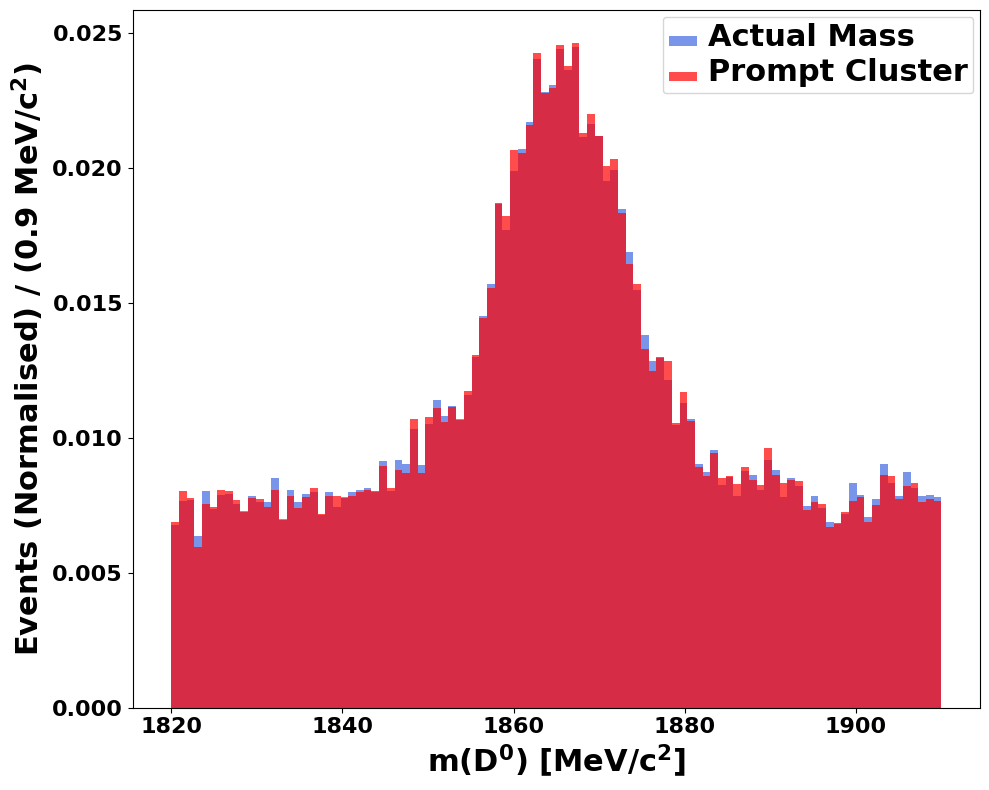

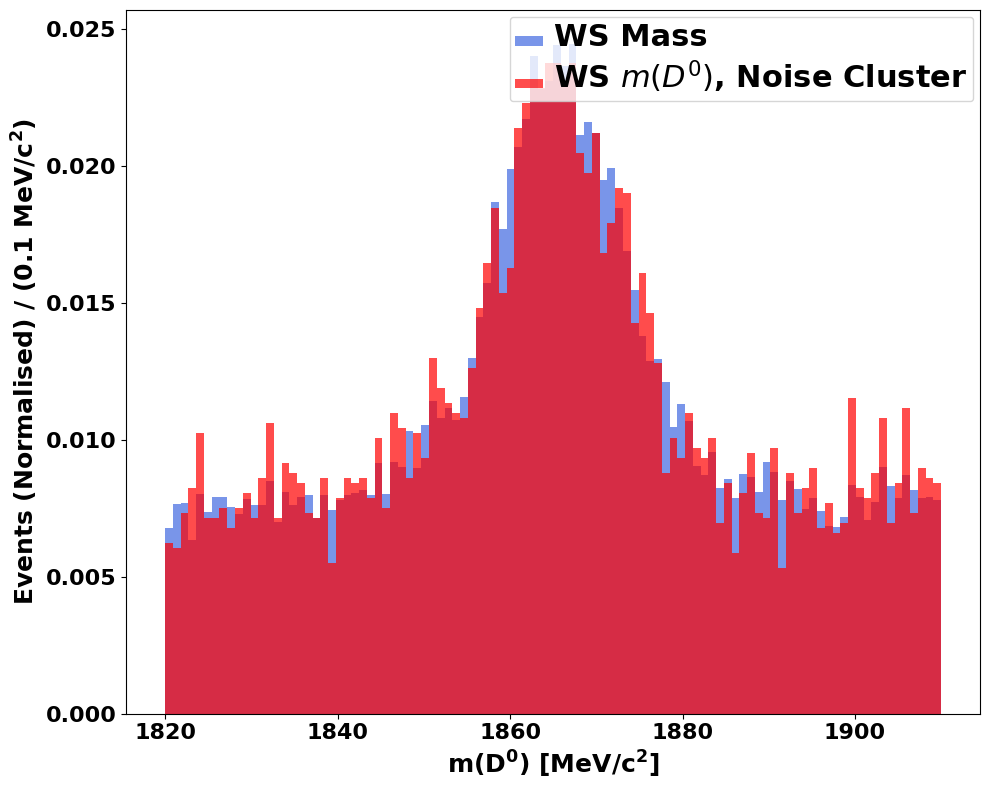

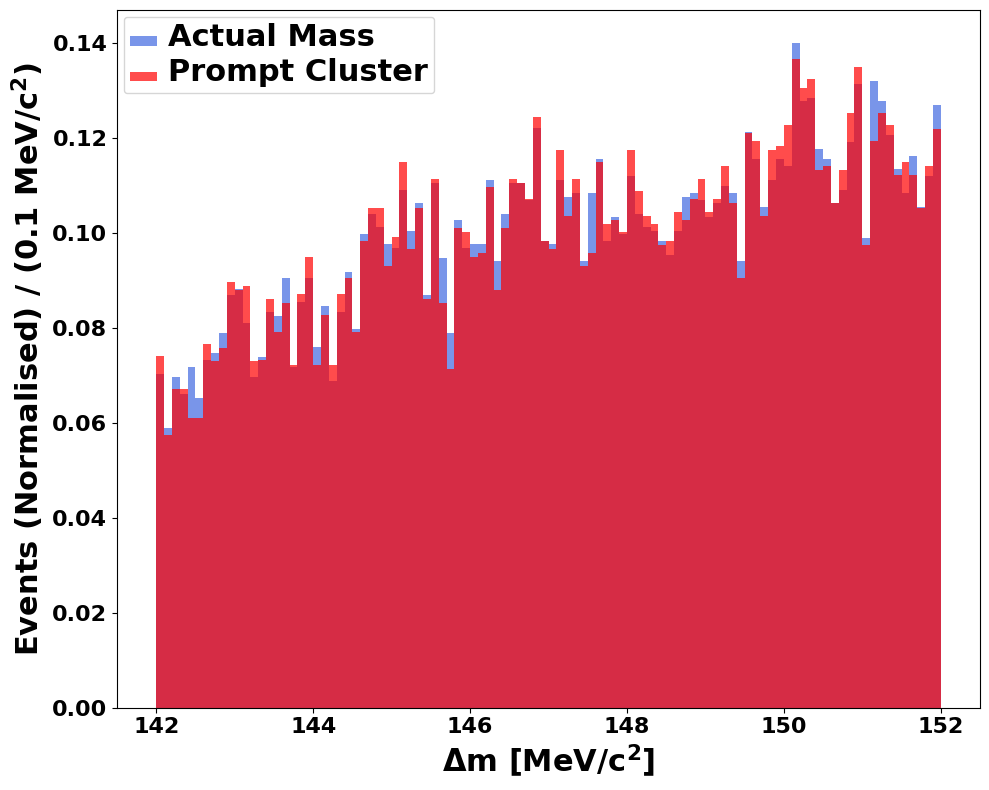

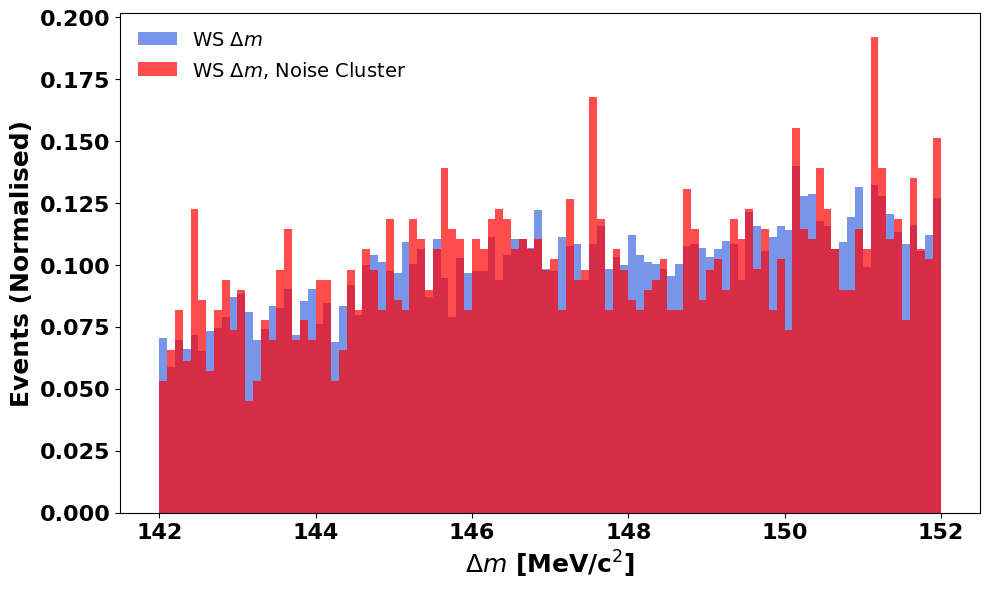

In [22]:
cluster0 = 0
cluster_minus1 = -1

# Filter events by cluster
cluster_events0_ws = data_ws[data_ws["cluster_labels"] == cluster0]
cluster_events_minus1_ws = data_ws[data_ws["cluster_labels"] == cluster_minus1]

data_ws.columns = data_ws.columns.astype(str)

data_ws['D0_MM'] = D0_MM_data_ws.sample(frac=1, random_state=1).values
data_ws['deltam_ReFit'] = deltam_ReFit_data_ws.sample(frac=1, random_state=1).values

# Extract mass variables for plotting
cluster_events0_D0_ws_plot = cluster_events0_ws['D0_MM']
cluster_events_minus1_D0_ws_plot = cluster_events_minus1_ws['D0_MM']
data_plot_D0_ws = data_ws['D0_MM']

cluster_events0_Deltam_ws_plot = cluster_events0_ws['deltam_ReFit']
cluster_events_minus1_Deltam_ws_plot = cluster_events_minus1_ws['deltam_ReFit']
data_plot_Deltam_ws = data_ws['deltam_ReFit']

# Plot D0_MM (Signal Cluster)
plt.figure(figsize=(10, 8))
plt.hist(data_plot_D0_ws, bins=100, alpha=0.7, color='royalblue', label='Actual Mass', density=True, range=[1820, 1910])
plt.hist(cluster_events0_D0_ws_plot, bins=100, alpha=0.7, color='red', label=f'Prompt Cluster', density=True, range=[1820, 1910])
#plt.title("RS Cluster Applied to WS Cluster; Signal Cluster Mass Plot", fontsize=20, fontweight='bold')
plt.xlabel(r"$\mathbf{m(D^0)}$ [MeV/$\mathbf{c^{2}}$]", fontsize=22, fontweight='bold')
plt.ylabel("Events (Normalised) / (0.9 MeV/$\mathbf{c^{2}}$)", fontsize=22, fontweight='bold')
legend = plt.legend(markerscale=4, fontsize=20, title_fontsize=30, prop={'weight': 'bold'})
for text in legend.get_texts():
    text.set_fontsize(22)
plt.xticks(fontsize=16, fontweight='bold')
plt.yticks(fontsize=16, fontweight='bold')
#plt.yscale('log')
plt.tight_layout()
plt.show()

# Plot D0_MM (Noise Cluster)
plt.figure(figsize=(10, 8))
plt.hist(data_plot_D0_ws, bins=100, alpha=0.7, color='royalblue', label='WS Mass', density=True, range=[1820, 1910])
plt.hist(cluster_events_minus1_D0_ws_plot, bins=100, alpha=0.7, color='red', label=f'WS $m(D^0)$, Noise Cluster', density=True, range=[1820, 1910])
#plt.title("RS Cluster Applied to WS Cluster; Noise Cluster Mass Plot", fontsize=20, fontweight='bold')
plt.xlabel(r"$\mathbf{m(D^0)}$ [MeV/$\mathbf{c^{2}}$]", fontsize=18, fontweight='bold')
plt.ylabel("Events (Normalised) / (0.1 MeV/$\mathbf{c^{2}}$)", fontsize=18, fontweight='bold')
legend = plt.legend(markerscale=4, fontsize=20, title_fontsize=30, prop={'weight': 'bold'})
for text in legend.get_texts():
    text.set_fontsize(22)
plt.xticks(fontsize=16, fontweight='bold')
plt.yticks(fontsize=16, fontweight='bold')
#plt.yscale('log')
plt.tight_layout()
plt.show()

# Plot deltam_ReFit (Signal Cluster)
plt.figure(figsize=(10, 8))
plt.hist(data_plot_Deltam_ws, bins=100, alpha=0.7, color='royalblue', label='Actual Mass', density=True, range=[142, 152])
plt.hist(cluster_events0_Deltam_ws_plot, bins=100, alpha=0.7, color='red', label=f'Prompt Cluster', density=True, range=[142, 152])
#plt.title("RS Cluster Applied to WS Cluster; Signal Cluster $\Delta m$ Plot", fontsize=20, fontweight='bold')
plt.xlabel(r"$\mathbf{\Delta m}$ [MeV/$\mathbf{c^{2}}$]", fontsize=22, fontweight='bold')
plt.ylabel("Events (Normalised) / (0.1 MeV/$\mathbf{c^{2}}$)", fontsize=22, fontweight='bold')
legend = plt.legend(markerscale=4, fontsize=20, title_fontsize=30, prop={'weight': 'bold'})
for text in legend.get_texts():
    text.set_fontsize(22)
plt.xticks(fontsize=16, fontweight='bold')
plt.yticks(fontsize=16, fontweight='bold')
#plt.yscale('log')
plt.tight_layout()
plt.show()

# Plot deltam_ReFit (Noise Cluster)
plt.figure(figsize=(10, 6))
plt.hist(data_plot_Deltam_ws, bins=100, alpha=0.7, color='royalblue', label='WS $\Delta m$', density=True, range=[142, 152])
plt.hist(cluster_events_minus1_Deltam_ws_plot, bins=100, alpha=0.7, color='red', label=f'WS $\Delta m$, Noise Cluster', density=True, range=[142, 152])
#plt.title("RS Cluster Applied to WS Cluster; Noise Cluster $\Delta m$ Plot", fontsize=20, fontweight='bold')
plt.xlabel(r"$\Delta m$ [MeV/c$^2$]", fontsize=18, fontweight='bold')
plt.ylabel("Events (Normalised)", fontsize=18, fontweight='bold')
plt.legend(fontsize=14, loc='upper left', frameon=False)
plt.xticks(fontsize=16, fontweight='bold')
plt.yticks(fontsize=16, fontweight='bold')
#plt.yscale('log')
plt.tight_layout()
plt.show()

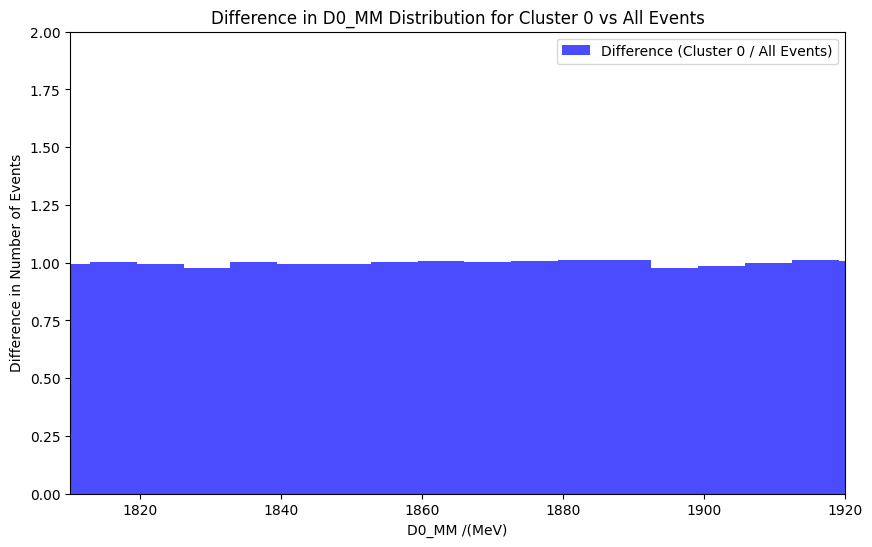

C:\Users\edwar\AppData\Local\Temp\ipykernel_144528\2638450487.py:22: RuntimeWarning: invalid value encountered in divide
  hist_diff1_ws = abs(hist_cluster1_ws / hist_all1_ws)


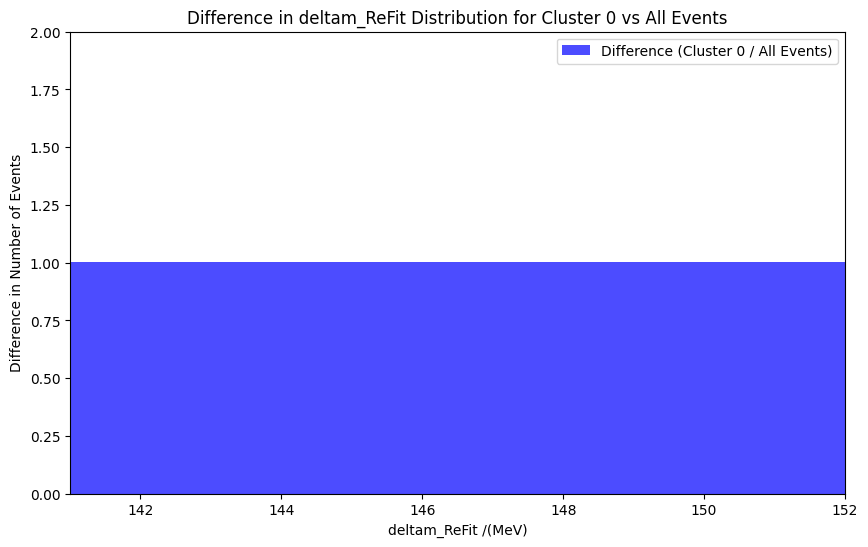

(50000, 13)


In [23]:
bins = np.linspace(min(data_ws['D0_MM']), max(data_ws['D0_MM']), 30)  # Define bin edges
bins1 = np.linspace(min(data_ws['deltam_ReFit']), max(data_ws['deltam_ReFit']), 30)
#All events
hist_all_ws, _ = np.histogram(data_ws['D0_MM'], bins=bins, density = True)
#Cluster0 events
hist_cluster0_ws, _ = np.histogram(cluster_events0_ws['D0_MM'], bins=bins, density = True)
hist_diff0_ws = abs(hist_cluster0_ws / hist_all_ws)

plt.figure(figsize=(10, 6))
plt.bar(bins[:-1], hist_diff0_ws, width=np.diff(bins), alpha=0.7, color='blue', label=f'Difference (Cluster {cluster0} / All Events)')
#plt.xlim(141,152)
plt.xlim(1810, 1920)
plt.ylim(0, 2)
plt.title(f"Difference in D0_MM Distribution for Cluster {cluster0} vs All Events")
plt.xlabel("D0_MM /(MeV)")
plt.ylabel("Difference in Number of Events")
plt.legend()
plt.show()

hist_all1_ws, _ = np.histogram(data_ws['deltam_ReFit'], bins=bins1, density = True)
hist_cluster1_ws, _ = np.histogram(cluster_events0_ws['deltam_ReFit'], bins=bins1, density = True)
hist_diff1_ws = abs(hist_cluster1_ws / hist_all1_ws)

plt.figure(figsize=(10, 6))
plt.bar(bins1[:-1], hist_diff1_ws, width=np.diff(bins1), alpha=0.7, color='blue', label=f'Difference (Cluster {cluster0} / All Events)')
plt.xlim(141,152)
plt.ylim(0, 2)
plt.title(f"Difference in deltam_ReFit Distribution for Cluster {cluster0} vs All Events")
plt.xlabel("deltam_ReFit /(MeV)")
plt.ylabel("Difference in Number of Events")
plt.legend()
plt.show()
print(data_ws.shape)